In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dolfin import Function, plot
def gr1(V, sol, levels=20, fs=(6.5,4)):
    u = Function(V); u.vector()[:] = sol
    plt.figure(figsize=fs)
    p = plot(u); plot(u, mode='contour', levels=levels, colors='k', linewidths=0.3)
    cax = make_axes_locatable(plt.gca()).append_axes('right', size="3%", pad=0.2)
    plt.colorbar(p, cax=cax); plt.tight_layout(); plt.show()

In [23]:
def gr2(x, y):
    plt.figure(figsize=(6,3))
    plt.plot(x, y, lw=2)
    plt.grid(alpha=0.3); plt.xlabel('x'); plt.ylabel('y')
    plt.tight_layout(); plt.show()

In [76]:
from dolfin import * ; import numpy as np
set_log_level(LogLevel.WARNING)
N = 100
T = 0.1; M = 100; tau = T/M

gamma = 100
def p(t):
    return -1000*t/(1 + np.exp(gamma*(t-0.5*T)))
def boundary(x):
    return x[0] < DOLFIN_EPS or x[0] > 1.0 - DOLFIN_EPS or \
        x[1] < DOLFIN_EPS or x[1] > 1.0 - DOLFIN_EPS

mesh = UnitSquareMesh(N, N)
V = FunctionSpace(mesh, "Lagrange", 1)

bc = DirichletBC(V, Constant(0.0), boundary)
u0 = interpolate(Expression("sin(pi*x[0])*sin(pi*x[1])", pi=np.pi, degree=2), V)
f  = Expression("sin(pi*x[0])*sin(pi*x[1])", pi=np.pi, degree=2)
p_cur = Constant(0.0)

u_trial = TrialFunction(V); v = TestFunction(V)
a = (1/tau)*inner(u_trial, v)*dx + inner(grad(u_trial), grad(v))*dx
L = (1/tau)*inner(u0, v)*dx - p_cur*inner(u0, v)*dx + inner(f, v)*dx

u = Function(V)
solutions = []

t = 0
while t < T:
    t += tau
    p_cur.assign(p(t))  # p^j на текущем шаге — ДО solve
    solve(a == L, u, bc)
    solutions.append(u.vector().get_local().copy())
    u0.assign(u)

solutions = np.array(solutions)
print(f"Прямая задача: {len(solutions)} шагов, max|u| = {np.max(np.abs(solutions)):.4f}")


Прямая задача: 100 шагов, max|u| = 1.0842


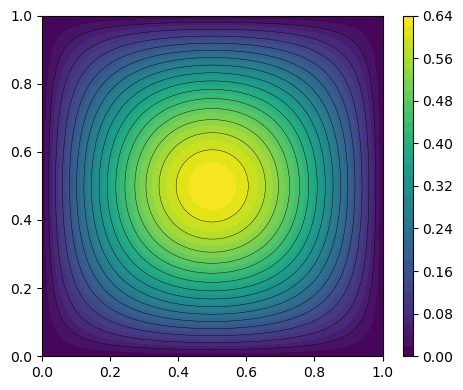

In [77]:
gr1(V, solutions[-1])

Функция переопределения $p(t)$

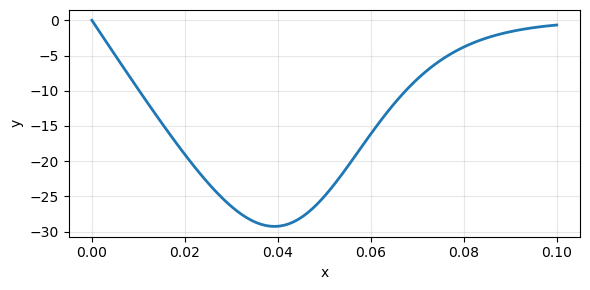

In [78]:
t = np.linspace(0, T, M)
gr2(t, p(t))

η должна совпадать с той, что используется в обратной задаче


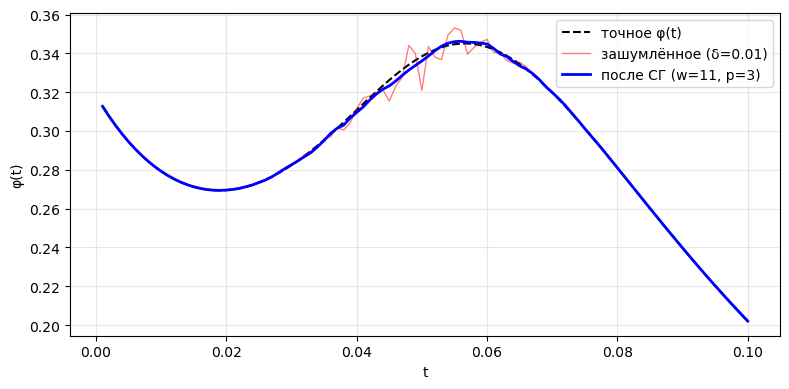

In [100]:
eta = Expression("x[0]*pi*x[1]", degree=2, pi=np.pi)
eta_fun = interpolate(eta, V)
phi_t = []
for sol in solutions:
    u_tmp = Function(V); u_tmp.vector()[:] = sol
    phi_t.append(assemble(eta_fun * u_tmp * dx))
    
phi_t = np.array(phi_t)

# 1. Зашумление φ(t)
delta = 0.01
np.random.seed(42)
noise = (delta * np.exp(-(10000*(t-T/2)**2 ) ) * np.random.randn(M))
phi_t_noisy = phi_t.copy() + noise

# 2. Сглаживание фильтром Савицкого-Голея
from scipy.signal import savgol_filter
phi_t_filtered = savgol_filter(phi_t_noisy, window_length=25, polyorder=5)

# 3. Визуализация
plt.figure(figsize=(8, 4))
tt = np.linspace(tau, T, M)
plt.plot(tt, phi_t,          "k--", lw=1.5, label="точное φ(t)")
plt.plot(tt, phi_t_noisy,    "r-",  lw=1,   alpha=0.5, label=f"зашумлённое (δ={delta})")
plt.plot(tt, phi_t_filtered, "b-",  lw=2,   label="после СГ (w=11, p=3)")
plt.legend(); plt.grid(alpha=0.3); plt.xlabel("t"); plt.ylabel("φ(t)")
plt.tight_layout(); plt.show()

# Подаём в алгоритм отфильтрованное
phi_t = phi_t_filtered


In [101]:
# η совпадает с тем, что использовалось при вычислении phi_t
eta_fun = interpolate(eta, V)
f = Expression("sin(pi*x[0])*sin(pi*x[1])", pi=np.pi, degree=2)

bc = DirichletBC(V, Constant(0.0), boundary)

u_tr = TrialFunction(V)
v_te = TestFunction(V)
# Одна матрица для z и ω
a_common = inner(u_tr, v_te)*dx + tau*inner(grad(u_tr), grad(v_te))*dx

# Начальное условие совпадает с прямой задачей
y0 = interpolate(Expression("sin(pi*x[0])*sin(pi*x[1])", pi=np.pi, degree=2), V)

z_ = Function(V)
w_ = Function(V)
y  = Function(V)
sol_z = []; sol_w = []; sol_y = []; sol_p = []

t = 0; j = 0
while t < T:
    t += tau

    L_z = inner(y0, v_te)*dx + tau*inner(f, v_te)*dx
    solve(a_common == L_z, z_, bc)

    L_w = -tau*inner(y0, v_te)*dx
    solve(a_common == L_w, w_, bc)

    eta_z = assemble(eta_fun * z_ * dx)
    eta_w = assemble(eta_fun * w_ * dx)

    if abs(eta_w) < 1e-14:
        raise RuntimeError(f"Знаменатель Iω ≈ 0 на шаге {j}")

    p_j = (phi_t[j] - eta_z) / eta_w

    y.vector()[:] = z_.vector().get_local() + p_j * w_.vector().get_local()
    sol_z.append(z_.vector().get_local().copy())
    sol_w.append(w_.vector().get_local().copy())
    sol_y.append(y.vector().get_local().copy())
    sol_p.append(p_j)
    y0.assign(y)
    j += 1

sol_z = np.array(sol_z)
sol_w = np.array(sol_w)
sol_y = np.array(sol_y)
sol_p = np.array(sol_p)
print(f"Обратная задача решена. p в диапазоне [{sol_p.min():.2f}, {sol_p.max():.2f}]")


Обратная задача решена. p в диапазоне [-31.51, -0.67]


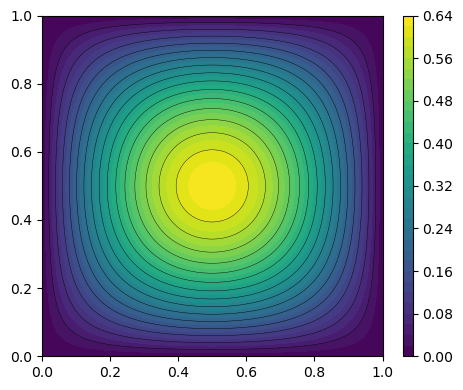

In [102]:
gr1(V, sol_y[-1])

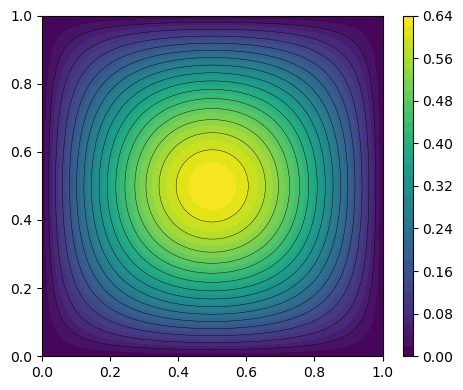

In [103]:
gr1(V, solutions[-1])

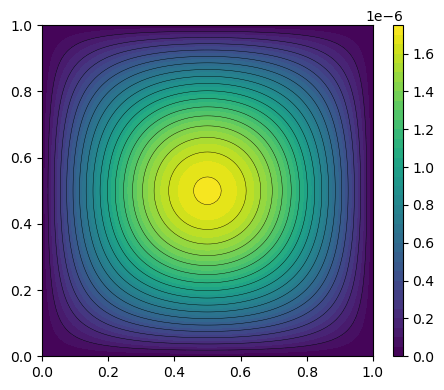

In [104]:
gr1(V, solutions[-1]-sol_y[-1])

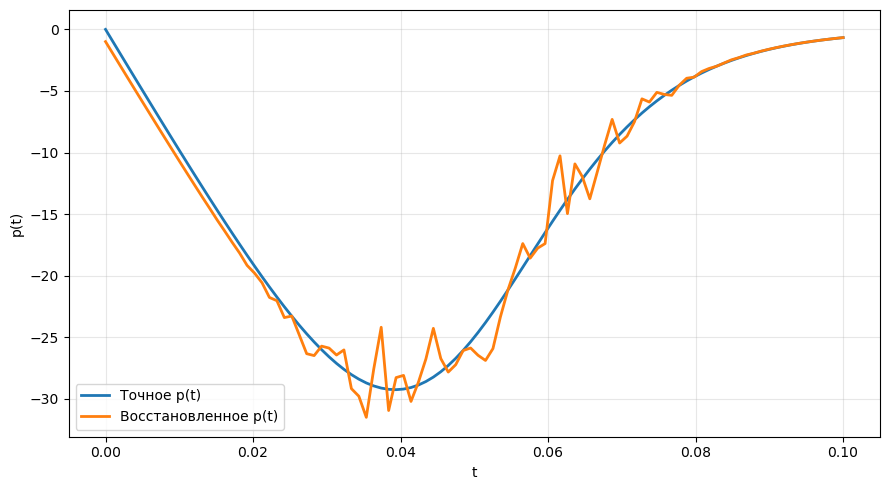

In [105]:
t = np.linspace(0, T, M)
plt.figure(figsize=(9,5))
plt.plot(t, p(t), lw=2, label='Точное p(t)')
plt.plot(t, sol_p, lw=2, label='Восстановленное p(t)')

plt.grid(alpha=0.3); plt.xlabel('t'); plt.ylabel('p(t)'); plt.legend()
plt.tight_layout(); plt.show()

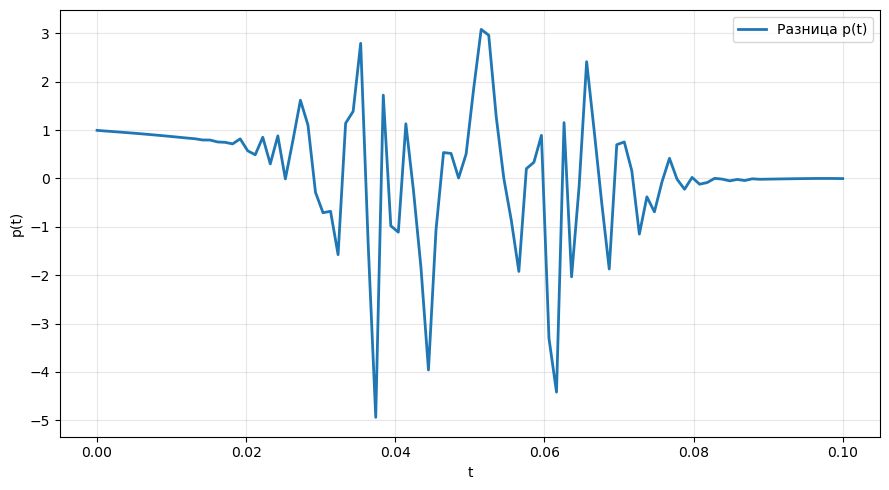

In [106]:
t = np.linspace(0, T, M)
plt.figure(figsize=(9,5))
plt.plot(t, p(t) - sol_p, lw=2, label='Разница p(t)')

plt.grid(alpha=0.3); plt.xlabel('t'); plt.ylabel('p(t)'); plt.legend()
plt.tight_layout(); plt.show()